In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [5]:
print(X.head())

       X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...    X14    X15    X16  \
0   20000   2   2   1  24   2   2  -1  -1   -2  ...    689      0      0   
1  120000   2   2   2  26  -1   2   0   0    0  ...   2682   3272   3455   
2   90000   2   2   2  34   0   0   0   0    0  ...  13559  14331  14948   
3   50000   2   2   1  37   0   0   0   0    0  ...  49291  28314  28959   
4   50000   1   2   1  57  -1   0  -1   0    0  ...  35835  20940  19146   

     X17   X18    X19    X20   X21   X22   X23  
0      0     0    689      0     0     0     0  
1   3261     0   1000   1000  1000     0  2000  
2  15549  1518   1500   1000  1000  1000  5000  
3  29547  2000   2019   1200  1100  1069  1000  
4  19131  2000  36681  10000  9000   689   679  

[5 rows x 23 columns]


In [4]:
print(y.head())

   Y
0  1
1  1
2  0
3  0
4  0


In [7]:
print(X.shape)
print(y.shape)

(30000, 23)
(30000, 1)


In [9]:
print(X.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
dtypes: int64(23)
memory us

In [10]:
print(y.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       30000 non-null  int64
dtypes: int64(1)
memory usage: 234.5 KB
None


In [8]:
print(X.describe())

                   X1            X2            X3            X4            X5  \
count    30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean    167484.322667      1.603733      1.853133      1.551867     35.485500   
std     129747.661567      0.489129      0.790349      0.521970      9.217904   
min      10000.000000      1.000000      0.000000      0.000000     21.000000   
25%      50000.000000      1.000000      1.000000      1.000000     28.000000   
50%     140000.000000      2.000000      2.000000      2.000000     34.000000   
75%     240000.000000      2.000000      2.000000      2.000000     41.000000   
max    1000000.000000      2.000000      6.000000      3.000000     79.000000   

                 X6            X7            X8            X9           X10  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      -0.016700     -0.133767     -0.166200     -0.220667     -0.266200   
std        1.123802      1.197186

In [11]:
print(y.describe())

                  Y
count  30000.000000
mean       0.221200
std        0.415062
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000


Y
0    23364
1     6636
Name: count, dtype: int64


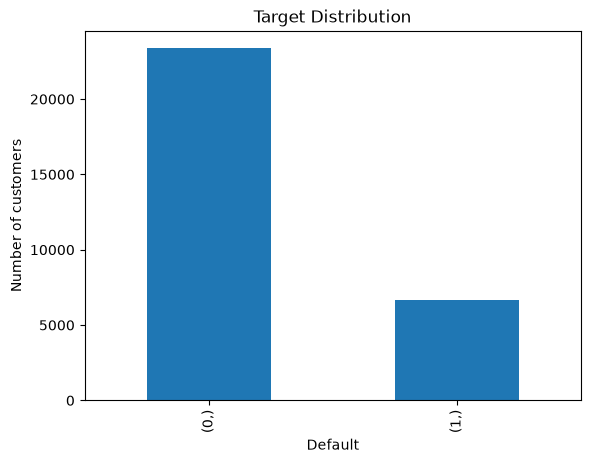

In [13]:
import matplotlib.pyplot as plt

print(y.value_counts())

y.value_counts().plot(kind="bar")

plt.xlabel("Default")
plt.ylabel("Number of customers")
plt.title("Target Distribution")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Y
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Test:
Y
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [18]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [19]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000))
])

In [20]:
logistic_pipeline.fit(X_train, y_train)

c:\Users\HARSHIT BAGGA\Desktop\Credit-card-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](23,)","['X1','X2','X3',...,'X21','X22','X23']"
n_features_in_,int,23
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [21]:
y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6723333333333333
Precision: 0.3613882863340564
Recall: 0.627731725697061
F1: 0.45870044052863435
ROC-AUC: 0.7104261505794724
PR-AUC: 0.4917396562128532

Confusion Matrix:
[[3201 1472]
 [ 494  833]]


In [23]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

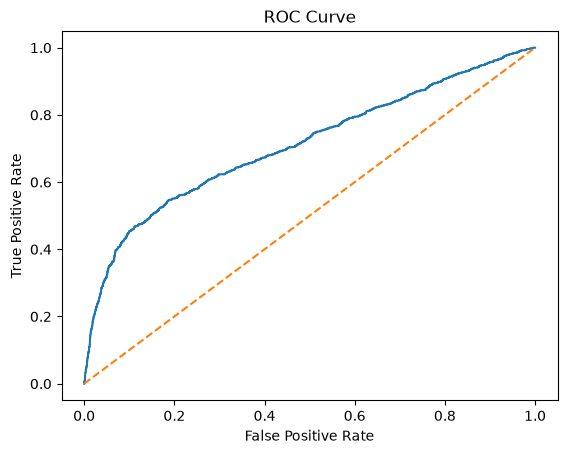

In [24]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

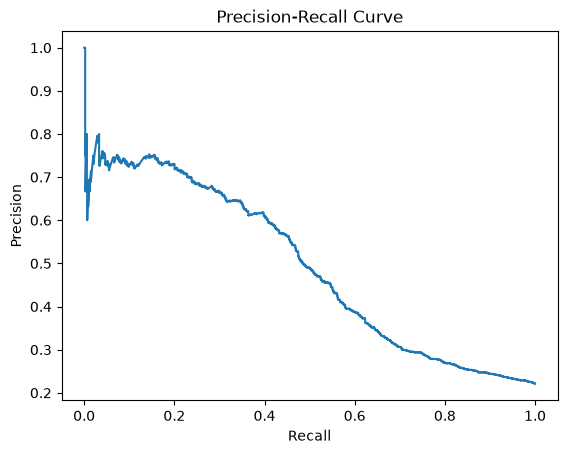

In [25]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression

logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000))
])

In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [28]:
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

In [29]:
from sklearn.tree import DecisionTreeClassifier

tree = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [32]:
from xgboost import XGBClassifier
xgb = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

In [33]:
from lightgbm import LGBMClassifier
lgbm = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ))
])

In [35]:
models = {
    "Logistic Regression": logistic,
    "KNN": knn,
    "SVM": svm,
    "Decision Tree": tree,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [37]:
results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean()
    }

In [38]:
import pandas as pd
results_df = pd.DataFrame(results).T

print(
    results_df.sort_values(
        by="PR-AUC",
        ascending=False
    )
)

                     Accuracy  Precision    Recall        F1   ROC-AUC  \
Gradient Boosting    0.757125   0.460405  0.567150  0.508190  0.753264   
LightGBM             0.778125   0.498542  0.503675  0.501068  0.753854   
SVM                  0.779917   0.502569  0.575063  0.536287  0.757968   
XGBoost              0.768500   0.479131  0.529103  0.502832  0.751985   
Logistic Regression  0.684875   0.377353  0.652481  0.478139  0.727943   
Random Forest        0.786667   0.518646  0.498587  0.508317  0.755241   
Decision Tree        0.742417   0.438254  0.536446  0.480731  0.722233   
KNN                  0.664583   0.351897  0.613299  0.447197  0.687265   

                       PR-AUC  
Gradient Boosting    0.505904  
LightGBM             0.505372  
SVM                  0.503741  
XGBoost              0.503566  
Logistic Regression  0.502952  
Random Forest        0.499525  
Decision Tree        0.460245  
KNN                  0.364739  


In [39]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)
best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
0.5123088545878203


In [40]:
y_pred = best_xgb.predict(X_test)

y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [41]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1:",
      f1_score(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

print("PR-AUC:",
      average_precision_score(y_test, y_prob))

Accuracy: 0.7626666666666667
Precision: 0.4687701223438506
Recall: 0.5486058779201206
F1: 0.5055555555555555
ROC-AUC: 0.7485887518462536
PR-AUC: 0.5125633526994682


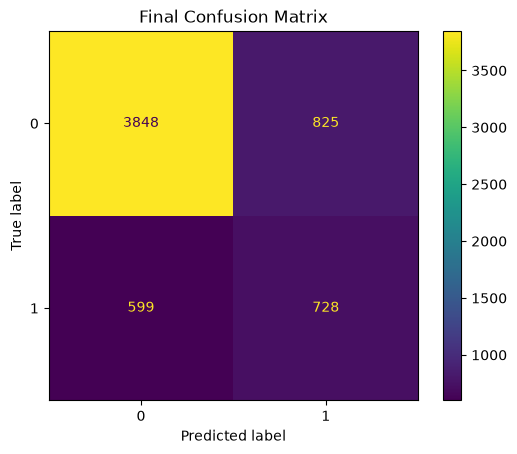

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Final Confusion Matrix")
plt.show()

In [43]:
import numpy as np

thresholds = np.arange(0.1, 0.91, 0.05)

for threshold in thresholds:

    y_threshold = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    print(
        f"Threshold={threshold:.2f} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold=0.10 | Precision=0.228 | Recall=0.987 | F1=0.371
Threshold=0.15 | Precision=0.247 | Recall=0.958 | F1=0.392
Threshold=0.20 | Precision=0.270 | Recall=0.906 | F1=0.416
Threshold=0.25 | Precision=0.293 | Recall=0.828 | F1=0.433
Threshold=0.30 | Precision=0.326 | Recall=0.772 | F1=0.459
Threshold=0.35 | Precision=0.360 | Recall=0.714 | F1=0.479
Threshold=0.40 | Precision=0.394 | Recall=0.656 | F1=0.493
Threshold=0.45 | Precision=0.430 | Recall=0.605 | F1=0.503
Threshold=0.50 | Precision=0.469 | Recall=0.549 | F1=0.506
Threshold=0.55 | Precision=0.497 | Recall=0.496 | F1=0.496
Threshold=0.60 | Precision=0.538 | Recall=0.451 | F1=0.491
Threshold=0.65 | Precision=0.586 | Recall=0.399 | F1=0.475
Threshold=0.70 | Precision=0.635 | Recall=0.332 | F1=0.436
Threshold=0.75 | Precision=0.677 | Recall=0.245 | F1=0.360
Threshold=0.80 | Precision=0.742 | Recall=0.158 | F1=0.261
Threshold=0.85 | Precision=0.798 | Recall=0.069 | F1=0.126
Threshold=0.90 | Precision=0.773 | Recall=0.013 | F1=0.0

In [44]:
importance = best_xgb.named_steps["model"].feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

X7     0.156408
X6     0.122448
X2     0.108933
X4     0.082564
X8     0.074774
X9     0.065958
X10    0.047630
X3     0.043463
X11    0.033100
X18    0.032429
X12    0.029190
X19    0.027465
X1     0.022339
X20    0.020539
X23    0.019634
X5     0.017620
X13    0.016594
X22    0.016083
X21    0.014328
X14    0.013837
X16    0.013307
X15    0.012067
X17    0.009290
dtype: float32


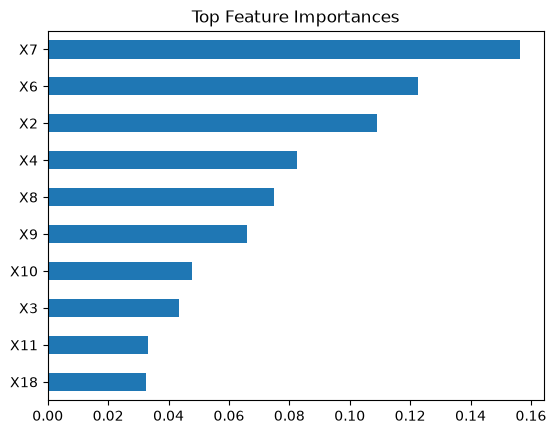

In [45]:
feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top Feature Importances")
plt.show()